## 6 Classifier Evaluation

This notebook evaluates our trained classifier.

In [ ]:
import sys
import os
from pathlib import Path
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from transformers import WhisperProcessor, WhisperForConditionalGeneration

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import load_all_data, extract_encoder_embeddings
from whisper_asr.utils import get_best_gpu

os.environ["TOKENIZERS_PARALLELISM"] = "false"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Selected GPU 6 with 24121 MiB free memory
Using device: cuda:6


Load processor, the finetuned model and the test data

In [5]:
MODEL_PATH = "../models/whisper-medium-rm-all-it"
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)
print("Model loaded.")
test_df = load_all_data("test")
test_labels = test_df["idiom"].tolist()

Loading weights: 100%|██████████| 947/947 [00:00<00:00, 5216.77it/s]


Model loaded.


Load classifier and extract encoder embeddings of the test set. Get the classifier predictions and evaluate them. Visualize via confusion matrix

Extracting encoder embeddings: 100%|██████████| 79/79 [00:55<00:00,  1.43it/s]

Absolute counts:
Predicted idiom  Puter  RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                          
Puter              112   0         1          0          0         1
RG                   0  80         1          0          0         0
Surmiran             0   0       151          0          0         0
Sursilvan            0   0         0         94          0         0
Sutsilvan            0   0         0          1         93         0
Vallader             2   0         1          0          0        94

Normalized (by true idiom):
Predicted idiom  Puter     RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                             
Puter            0.982  0.000     0.009      0.000      0.000     0.009
RG               0.000  0.988     0.012      0.000      0.000     0.000
Surmiran         0.000  0.000     1.000      0.000      0.000     0.000
Sursilvan        0.000  0.000     0.000   

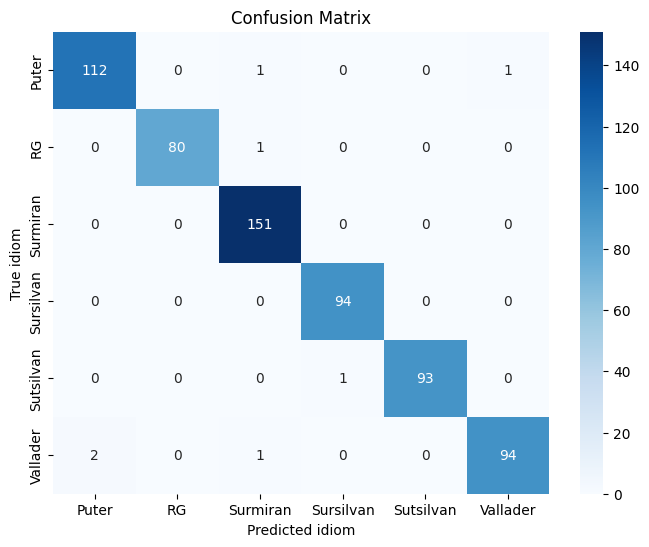

In [ ]:
classifier = joblib.load("../models/idiom_classifier.pkl")
test_embeddings = extract_encoder_embeddings(
    model, processor,
    test_df["audio_path"].tolist(),
    device=DEVICE, batch_size=8
)
predictions = classifier.predict(test_embeddings)
cm = confusion_matrix(test_labels, predictions, labels=classifier.classes_)

cm_df = pd.DataFrame(cm, index=classifier.classes_, columns=classifier.classes_)
cm_df.index.name = "True idiom"
cm_df.columns.name = "Predicted idiom"

print("Absolute counts:")
print(cm_df)

cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3)
print("\nNormalized (by true idiom):")
print(cm_norm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

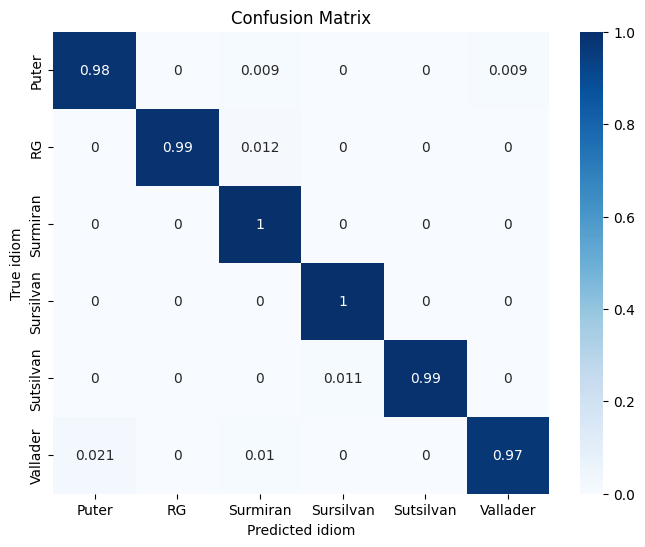

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()